<a href="https://colab.research.google.com/github/Saisohangoud/AI-Job-Market-Analyzer/blob/main/AI_Job_Market_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FIRST 5 ROWS:
    job_id              job_title  salary_usd salary_currency  \
0  AI00001  AI Research Scientist       90376             USD   
1  AI00002   AI Software Engineer       61895             USD   
2  AI00003          AI Specialist      152626             USD   
3  AI00004           NLP Engineer       80215             USD   
4  AI00005          AI Consultant       54624             EUR   

  experience_level employment_type company_location company_size  \
0               SE              CT            China            M   
1               EN              CT           Canada            M   
2               MI              FL      Switzerland            L   
3               SE              FL            India            M   
4               EN              PT           France            S   

  employee_residence  remote_ratio  \
0              China            50   
1            Ireland           100   
2        South Korea             0   
3              India            50

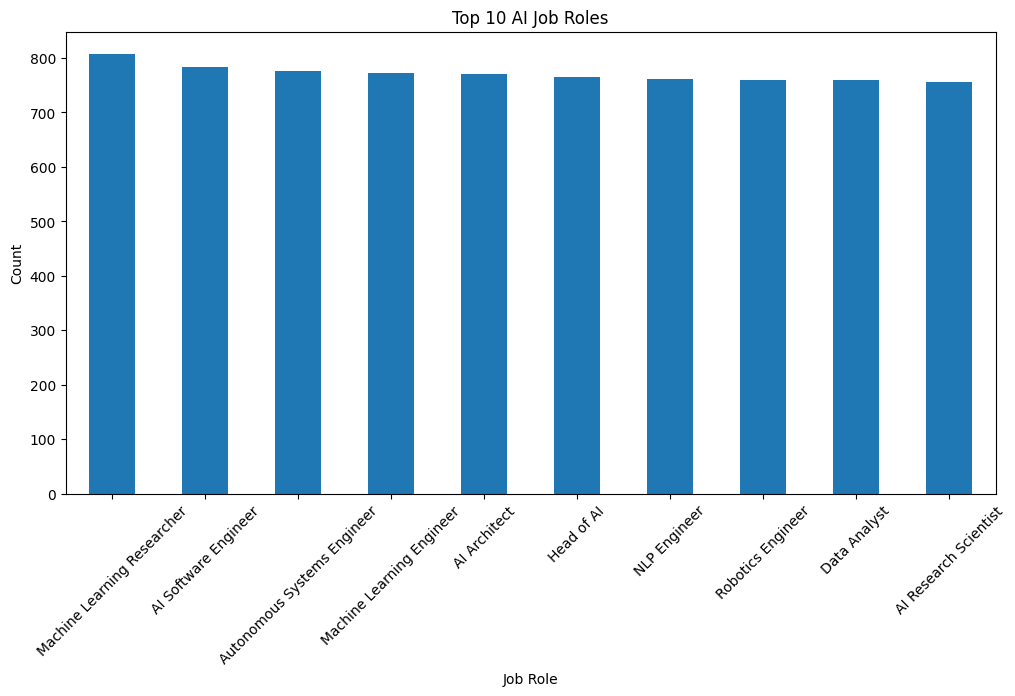

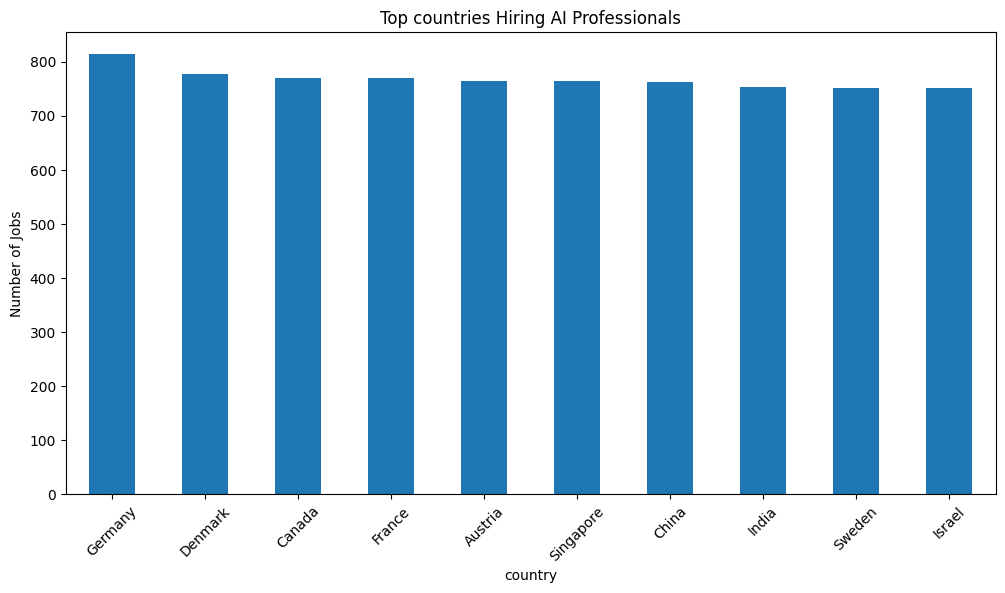

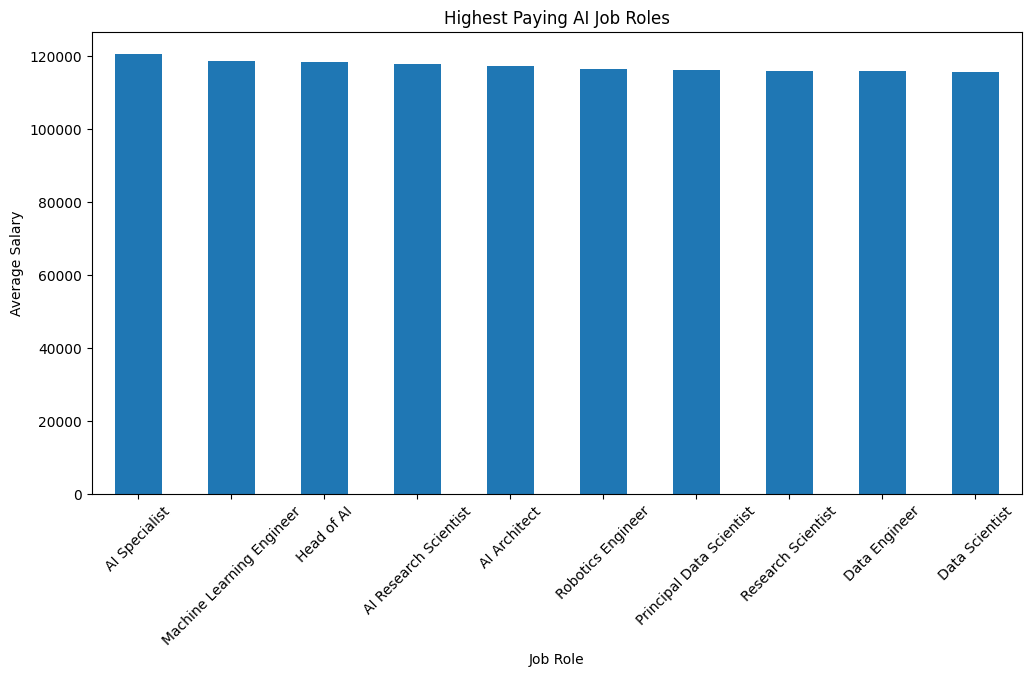


MODEL TRAINED SUCCESSFULLY!

MODEL PERFORMANCE:
Mean Absolute Error: 42660.21979030216
R2 Score: 0.18999326087424162

PREDICTED SALARY:
$127,027.85


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


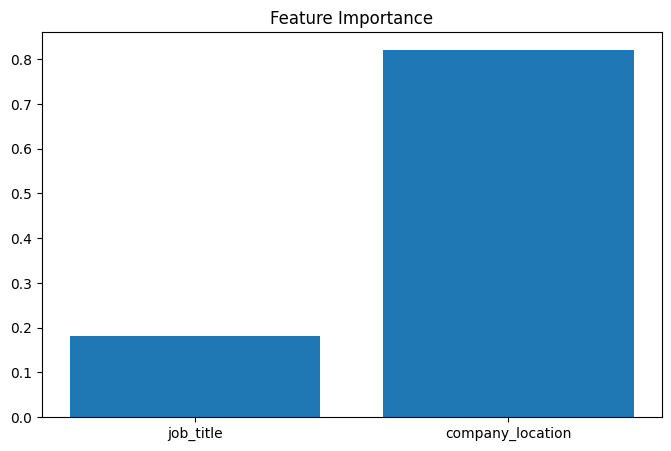


MODEL SAVED SUCCESSFULLY!

AI JOB MARKET ANALYZER PROJECT COMPLETED SUCCESSFULLY!


In [7]:
# ============================================
# AI JOB MARKET ANALYZER PROJECT
# COMPLETE CODE - GOOGLE COLAB
# ============================================

# Install libraries if needed
!pip install pandas matplotlib scikit-learn

# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# ============================================
# LOAD DATASET
# ============================================

# Upload your dataset file into Colab first
# Replace filename if different

df = pd.read_csv('/content/ai_job_dataset.csv')

# ============================================
# SHOW DATASET
# ============================================

print("FIRST 5 ROWS:")
print(df.head())

print("\nDATASET SHAPE:")
print(df.shape)

print("\nCOLUMN NAMES:")
print(df.columns)

# ============================================
# DATASET INFORMATION
# ============================================

print("\nDATASET INFO:")
print(df.info())

print("\nMISSING VALUES:")
print(df.isnull().sum())

print("\nSTATISTICS:")
print(df.describe())

# ============================================
# REMOVE MISSING VALUES
# ============================================

df = df.dropna()

# ============================================
# TOP JOB ROLES VISUALIZATION
# ============================================

plt.figure(figsize=(12,6))

df['job_title'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 AI Job Roles')
plt.xlabel('Job Role')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

# ============================================
# TOP COUNTRIES HIRING
# ============================================

plt.figure(figsize=(12,6))

df['company_location'].value_counts().head(10).plot(kind='bar')

plt.title('Top countries Hiring AI Professionals')
plt.xlabel('country')
plt.ylabel('Number of Jobs')

plt.xticks(rotation=45)

plt.show()

# ============================================
# AVERAGE SALARY BY JOB ROLE
# ============================================

avg_salary = df.groupby('job_title')['salary_usd'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

avg_salary.plot(kind='bar')

plt.title('Highest Paying AI Job Roles')
plt.xlabel('Job Role')
plt.ylabel('Average Salary')

plt.xticks(rotation=45)

plt.show()

# ============================================
# ENCODE CATEGORICAL DATA
# ============================================

le_job = LabelEncoder()
le_country = LabelEncoder()

df['job_title'] = le_job.fit_transform(df['job_title'])
df['company_location'] = le_country.fit_transform(df['company_location'])

# ============================================
# FEATURES AND TARGET
# ============================================

X = df[['job_title', 'company_location']]
y = df['salary_usd']

# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================
# TRAIN MACHINE LEARNING MODEL
# ============================================

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nMODEL TRAINED SUCCESSFULLY!")

# ============================================
# PREDICTIONS
# ============================================

y_pred = model.predict(X_test)

# ============================================
# MODEL EVALUATION
# ============================================

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMODEL PERFORMANCE:")
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

# ============================================
# SAMPLE SALARY PREDICTION
# ============================================

# Example:
# Data Scientist in USA

sample_job = le_job.transform(['Data Scientist'])[0]
sample_country = le_country.transform(['United States'])[0]

sample_input = [[sample_job, sample_country]]

predicted_salary = model.predict(sample_input)

print("\nPREDICTED SALARY:")
print(f"${predicted_salary[0]:,.2f}")

# ============================================
# FEATURE IMPORTANCE
# ============================================

importance = model.feature_importances_

feature_names = X.columns

plt.figure(figsize=(8,5))

plt.bar(feature_names, importance)

plt.title('Feature Importance')

plt.show()

# ============================================
# SAVE MODEL
# ============================================

import joblib

joblib.dump(model, 'salary_prediction_model.pkl')

print("\nMODEL SAVED SUCCESSFULLY!")

# ============================================
# PROJECT COMPLETED
# ============================================

print("\nAI JOB MARKET ANALYZER PROJECT COMPLETED SUCCESSFULLY!")